# Hochschule für Bildende Künste Braunschweig - Mapping

In [5]:
from google.cloud import bigquery
import pandas as pd
from typing import Union
import re
import json
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
sns.set_style('whitegrid')
plt.rc('font', family='Arial')
plt.rc('font', size=9) 
plt.rc('axes', titlesize=9) 
plt.rc('axes', labelsize=9) 
plt.rc('xtick', labelsize=9) 
plt.rc('ytick', labelsize=9) 
plt.rc('legend', fontsize=9)

In [7]:
client = bigquery.Client(project='subugoe-collaborative')

In [8]:
oal = client.query(f"""
                    SELECT 
                        'not assigned' AS inst_name,
                        'Hochschule für Bildende Künste Braunschweig' AS parent_name,
                        raw_affiliation_string,
                        openalex_id
                    FROM (
                      SELECT oal.id AS openalex_id, inst.address_full AS raw_affiliation_string
                      FROM `subugoe-collaborative.resources.kb_a_addr_inst_202603` AS inst
                      JOIN `subugoe-collaborative.resources.add_institution_lookup_kb_suppl_202603` AS kb_inst
                          ON inst.inst_id_top = kb_inst.inst_id
                      JOIN `subugoe-collaborative.openalex_walden.works` AS oal
                          ON CONCAT('https://openalex.org/', inst.item_id) = oal.id
                      WHERE oal.type IN ('article', 'review') 
                          AND kb_inst.ror = 'https://ror.org/03aft2f80' -- 'Hochschule für Bildende Künste Braunschweig'
                          AND is_paratext=FALSE 
                          AND is_retracted=FALSE 
                          AND is_xpac=FALSE
                          AND publication_year BETWEEN 2020 AND 2025
                    )
                    """).to_dataframe()

In [9]:
oal.head()

,inst_name,parent_name,raw_affiliation_string,openalex_id
0,not assigned,Hochschule für Bildende Künste Braunschweig,Chair of Institute for Design Research (Retire...,https://openalex.org/W4298127992
1,not assigned,Hochschule für Bildende Künste Braunschweig,"Braunschweig University of Art,Chair of Instit...",https://openalex.org/W4298127992
2,not assigned,Hochschule für Bildende Künste Braunschweig,"Institut für Designforschung, Hochschule für B...",https://openalex.org/W4396670629
3,not assigned,Hochschule für Bildende Künste Braunschweig,"Braunschweig University of Art (HBK) , Braunsc...",https://openalex.org/W4404527831
4,not assigned,Hochschule für Bildende Künste Braunschweig,Hochschule für Bildende Künste Braunschweig [B...,https://openalex.org/W4388900930


In [10]:
MAPPING_DICT = {
    'Institut für Designforschung (IDF)': ['designforschung', 'design research'],
    'Institut für Kunstwissenschaft (IKW)': ['kunstwissenschaft', 'art studies'],
    'Institut für Medienwissenschaft (IMW)': ['medienwissenschaft', 'media studies'],
    'Institut Performative Praxis, Kunst und Bildung (IPKB)': ['performativ']
}

In [11]:
with open('./mapping_tables_fak/hbk.json', mode='w', encoding='utf-8') as f:
    json.dump(MAPPING_DICT, f, ensure_ascii=False)

In [12]:
def map_address(address: str) -> Union[str, None]:
    for k, v in MAPPING_DICT.items():
        pattern = re.compile(r'|'.join(v), re.IGNORECASE)
        res = bool(pattern.search(address))
        if res:
            return k
    return None

In [13]:
df_with_inst = oal.copy()

df_with_inst.loc[df_with_inst['inst_name'] == 'not assigned', 'inst_name'] = \
           df_with_inst.loc[df_with_inst['inst_name'] == 'not assigned']['raw_affiliation_string'].apply(map_address)

In [14]:
df_with_inst

,inst_name,parent_name,raw_affiliation_string,openalex_id
0,Institut für Designforschung (IDF),Hochschule für Bildende Künste Braunschweig,Chair of Institute for Design Research (Retire...,https://openalex.org/W4298127992
1,Institut für Designforschung (IDF),Hochschule für Bildende Künste Braunschweig,"Braunschweig University of Art,Chair of Instit...",https://openalex.org/W4298127992
2,Institut für Designforschung (IDF),Hochschule für Bildende Künste Braunschweig,"Institut für Designforschung, Hochschule für B...",https://openalex.org/W4396670629
3,None,Hochschule für Bildende Künste Braunschweig,"Braunschweig University of Art (HBK) , Braunsc...",https://openalex.org/W4404527831
4,None,Hochschule für Bildende Künste Braunschweig,Hochschule für Bildende Künste Braunschweig [B...,https://openalex.org/W4388900930
5,Institut für Designforschung (IDF),Hochschule für Bildende Künste Braunschweig,"Braunschweig University of Art, Institute for ...",https://openalex.org/W4321767620
6,Institut für Designforschung (IDF),Hochschule für Bildende Künste Braunschweig,"Braunschweig University of Art, Institute for ...",https://openalex.org/W4321767620
7,Institut für Designforschung (IDF),Hochschule für Bildende Künste Braunschweig,"Braunschweig University of Art, Institute for ...",https://openalex.org/W4321767620
8,None,Hochschule für Bildende Künste Braunschweig,Hochschule für Bildende Künste Braunschweig (HBK),https://openalex.org/W4293863852
9,None,Hochschule für Bildende Künste Braunschweig,"Dr. Theol., Pastor em., Liturgie- und Architek...",https://openalex.org/W3202857649


In [15]:
df_with_inst[df_with_inst.inst_name.isnull()].raw_affiliation_string.unique()

array(['Braunschweig University of Art (HBK) , Braunschweig , Germany',
       'Hochschule für Bildende Künste Braunschweig [Braunschweig University of Art] Germany',
       'Hochschule für Bildende Künste Braunschweig (HBK)',
       'Dr. Theol., Pastor em., Liturgie- und Architekturwissenschaftler, Wissen schaft licher Referent im EKD-Institut für Qualität im Gottesdienst Hildesheim, Lehrbeauftragtrer an der Hochschule für Bildende Künste Braunschweig , Drenkriede 13, D-30657 Hannover, Deutschland',
       'ISNI: 0000000122430966 Braunschweig University of Art'],
      dtype=object)

In [16]:
df_with_inst.groupby(['inst_name'], dropna=False)['openalex_id'].count().reset_index()

,inst_name,openalex_id
0,Institut für Designforschung (IDF),7
1,NaN,5


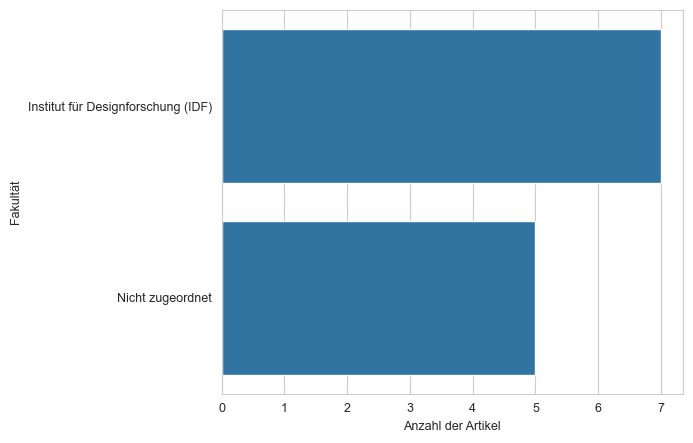

In [17]:
df_plot = df_with_inst.groupby(['inst_name'], dropna=False)['openalex_id'].count().reset_index()
df_plot.fillna('Nicht zugeordnet', inplace=True)

fig, ax = plt.subplots(figsize=(7, 4.5))

sns.barplot(data=df_plot, 
            x='openalex_id', 
            y='inst_name',
            ax=ax)

ax.set(xlabel='Anzahl der Artikel', ylabel='Fakultät')

plt.tight_layout()

plt.show()

In [18]:
df_plot[df_plot.inst_name != 'Nicht zugeordnet'].openalex_id.sum() / df_plot.openalex_id.sum()

0.5833333333333334

In [19]:
MAPPING_DICT_DEPT = {}
MAPPING_DICT_INST = {}

In [20]:
gerit_ids = pd.read_csv('../../data/gerit_inst_with_ids.csv')
gerit_ids = gerit_ids[gerit_ids.parent_name == 'Hochschule für Bildende Künste Braunschweig'][['inst_name', 'dfg_id']].to_dict(orient='records')

def search_gerit_id(name: str):  
    for gerit_id in gerit_ids:
        if gerit_id['inst_name'] == name:
            return gerit_id.get('dfg_id')

uni_dicts = dict()

for faculty, faculty_patterns in MAPPING_DICT.items():

    faculty_dict = dict()

    faculty_dict['faculty_id'] = search_gerit_id(faculty)
    faculty_dict['faculty_patterns'] = faculty_patterns

    faculty_suborganisations = dict()
    
    if MAPPING_DICT_DEPT.get(faculty):
        for department, department_patterns in MAPPING_DICT_DEPT.get(faculty).items():

            department_dict = dict()
            
            department_dict['department_id'] = search_gerit_id(department)
            department_dict['department_patterns'] = department_patterns

            department_suborganisations = dict()
            
            if MAPPING_DICT_INST.get(department):
                for institute, institute_patterns in MAPPING_DICT_INST.get(department).items():

                    institute_dict = dict()
            
                    institute_dict['institute_id'] = search_gerit_id(institute)
                    institute_dict['institute_patterns'] = institute_patterns

                    department_suborganisations[institute] = institute_dict
                    
            department_dict['suborganisations'] = department_suborganisations

            faculty_suborganisations[department] = department_dict

    faculty_dict['suborganisations'] = faculty_suborganisations

    uni_dicts[faculty] = faculty_dict

with open('../../data/mappings/hbk.json', mode='w', encoding='utf-8') as f:
    json.dump(uni_dicts, f, ensure_ascii=False)